# Floors, figures and tables

Reads the two summary tables, measures the biological and technical replicate
floors, and writes:

* Figure 3  - compartment metrics vs depth
* Figure 4  - saddle plots at five depths
* Figure 5  - insulation metrics vs depth, 100 kb window
* Figure S2 - the same at the 50 kb window
* Figure S3 - boundary recall at four tolerances
* Tables S4 and S5

In [23]:
import sys
import warnings
from itertools import combinations

warnings.filterwarnings("ignore")
import logging
logging.getLogger("fontTools").setLevel(logging.WARNING)

sys.path.insert(0, "other")
from hic_common import *

import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42
matplotlib.rc("font", family="DejaVu Sans", weight="medium", size=13)

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

BIO_COLOR = "#C44E52"    # biological  floor
TECH_COLOR = "#CCCC00"   # technical  floor

comp_summary = pd.read_parquet(DATASETS_DIR / "compartments_summary.parquet")
insul_summary = pd.read_parquet(DATASETS_DIR / "insulation_summary.parquet")

print(f"libraries:: {len(LIBRARIES)}")

libraries:: 9


## Replicate floors

Two kinds of floors:

* metrics that compare two tracks (correlation, recall, F1) - the floor is the
  mean value between full-depth replicates of the same group (bio/tech);
* metrics that are a number per library (compartment strength, boundary count
  and strength) - the floor is 100% plus or minus the mean CV inside a group (bio/tech).

In [21]:
import gc
from itertools import combinations

FLOOR_WINDOW = 100_000
FLOOR_TOLERANCE = 2

TECH_AS_GROUPS = {name: [(name, srr) for srr in srrs]
                  for name, srrs in TECH_GROUPS.items()}


def compartment_floor_pairs(groups):
    '''Pairwise E1 comparisons between full-depth replicates of each group.'''
    rows = []
    for name, members in groups.items():
        tracks = {}
        for sample_name, srr in members:
            path = eigs_path(sample_name, f"{srr}_full")
            if is_cached(path):
                tracks[srr] = load_eigs(sample_name, f"{srr}_full")

        for s1, s2 in combinations(sorted(tracks), 2):
            cor = track_correlations(tracks[s1], tracks[s2], "E1")
            sgn = sign_agreement(tracks[s1], tracks[s2], "E1")
            rows.append(dict(group=name, srr1=s1, srr2=s2,
                             E1_pearson=cor["pearson"],
                             E1_spearman=cor["spearman"],
                             E1_sign_agree=sgn))
        del tracks; gc.collect()
    return pd.DataFrame(rows)


def insulation_floor_pairs(groups):
    '''Pairwise insulation comparisons between full-depth replicates.

    b_recall is (recall + precision) / 2 because between two replicates
    there is no natural test/reference direction.
    '''
    score_col = f"log2_insulation_score_{FLOOR_WINDOW}"
    boundary_col = f"is_boundary_{FLOOR_WINDOW}"

    rows = []
    for name, members in groups.items():
        tracks = {}
        for sample_name, srr in members:
            path = insulation_path(sample_name, f"{srr}_full")
            if is_cached(path):
                tracks[srr] = load_insulation(sample_name, f"{srr}_full")

        for s1, s2 in combinations(sorted(tracks), 2):
            cor = track_correlations(tracks[s1], tracks[s2], score_col)
            b1 = tracks[s1].loc[tracks[s1][boundary_col] == True,
                                ["chrom", "start", "end"]]
            b2 = tracks[s2].loc[tracks[s2][boundary_col] == True,
                                ["chrom", "start", "end"]]
            mb = match_boundary_sets(b1, b2, RES_INSULATION, FLOOR_TOLERANCE)
            rows.append(dict(group=name, srr1=s1, srr2=s2,
                             ins_pearson=cor["pearson"],
                             b_recall=(mb["recall"] + mb["precision"]) / 2,
                             b_f1=mb["f1"]))
        del tracks; gc.collect()
    return pd.DataFrame(rows)


def absolute_spread(groups, load_fn, extract_fn, group_col="group"):
    '''Per-group mean, sd, CV of an absolute metric across replicates.

    load_fn(sample_name, srr) loads cached data for one full-depth library.
    extract_fn(data) returns a dict of {metric_name: value}.
    '''
    rows = []
    for name, members in groups.items():
        for sample_name, srr in members:
            try:
                data = load_fn(sample_name, srr)
            except Exception:
                continue
            row = {group_col: name, "sample_name": sample_name, "srr": srr}
            row.update(extract_fn(data))
            rows.append(row)
    df = pd.DataFrame(rows)

    spread_rows = []
    for name, sub in df.groupby(group_col):
        if len(sub) < 2:
            continue
        row = {group_col: name, "n": len(sub)}
        for col in [c for c in sub.columns if c not in (group_col, "sample_name", "srr")]:
            row[f"{col}_mean"] = sub[col].mean()
            row[f"{col}_sd"] = sub[col].std()
            row[f"{col}_cv"] = 100 * sub[col].std() / abs(sub[col].mean())
        spread_rows.append(row)
    return pd.DataFrame(spread_rows)


def load_comp_strength(sample_name, srr):
    '''Load the compartment strength of a full-depth library.'''
    return load_saddle(sample_name, f"{srr}_full")

def load_insul_absolute(sample_name, srr):
    '''Load the boundary count and mean strength of a full-depth library.'''
    return load_insulation(sample_name, f"{srr}_full")


def extract_comp_strength(data):
    return {"comp_strength": data["strength"]}

def extract_insul_absolute(ins):
    bcol = f"is_boundary_{FLOOR_WINDOW}"
    scol = f"boundary_strength_{FLOOR_WINDOW}"
    boundaries = ins.loc[ins[bcol] == True]
    return {"n_boundaries": len(boundaries),
            "mean_boundary_strength": float(ins[scol].dropna().mean())}


# pairwise
comp_bio_pairs = compartment_floor_pairs(BIO_GROUPS)
comp_tech_pairs = compartment_floor_pairs(TECH_AS_GROUPS)
insul_bio_pairs = insulation_floor_pairs(BIO_GROUPS)
insul_tech_pairs = insulation_floor_pairs(TECH_AS_GROUPS)

# absolute spread
comp_bio_spread = absolute_spread(BIO_GROUPS, load_comp_strength, extract_comp_strength)
comp_tech_spread = absolute_spread(TECH_AS_GROUPS, load_comp_strength, extract_comp_strength)
insul_bio_spread = absolute_spread(BIO_GROUPS, load_insul_absolute, extract_insul_absolute)
insul_tech_spread = absolute_spread(TECH_AS_GROUPS, load_insul_absolute, extract_insul_absolute)

save_parquet(comp_bio_pairs, DATASETS_DIR / "floor_pairs_compartments_bio.parquet")
save_parquet(comp_tech_pairs, DATASETS_DIR / "floor_pairs_compartments_tech.parquet")
save_parquet(insul_bio_pairs, DATASETS_DIR / "floor_pairs_insulation_bio.parquet")
save_parquet(insul_tech_pairs, DATASETS_DIR / "floor_pairs_insulation_tech.parquet")

pairwise: 77 bio / 193 tech (compartments)
pairwise: 77 bio / 193 tech (insulation)
absolute: 8 bio / 6 tech groups (comp strength)
absolute: 8 bio / 6 tech groups (insulation)


In [22]:
def pair_floor(pairs, column):
    '''Floor of a pairwise metric: mean within each group, then mean across groups (%).'''
    return 100 * pairs.groupby("group")[column].mean().mean()


def cv_floor(spread, column):
    '''Floor of an absolute metric: mean of per-group CVs (%).'''
    cv_col = f"{column}_cv"
    return float(spread[cv_col].mean())


# compartments
floor_bio_E1 = pair_floor(comp_bio_pairs, "E1_pearson")
floor_tech_E1 = pair_floor(comp_tech_pairs, "E1_pearson")
floor_bio_E1_spearman = pair_floor(comp_bio_pairs, "E1_spearman")
floor_tech_E1_spearman = pair_floor(comp_tech_pairs, "E1_spearman")
floor_bio_E1_sign = pair_floor(comp_bio_pairs, "E1_sign_agree")
floor_tech_E1_sign = pair_floor(comp_tech_pairs, "E1_sign_agree")
floor_bio_strength = cv_floor(comp_bio_spread, "comp_strength")
floor_tech_strength = cv_floor(comp_tech_spread, "comp_strength")

# insulation
floor_bio_ins = pair_floor(insul_bio_pairs, "ins_pearson")
floor_tech_ins = pair_floor(insul_tech_pairs, "ins_pearson")
floor_bio_recall = pair_floor(insul_bio_pairs, "b_recall")
floor_tech_recall = pair_floor(insul_tech_pairs, "b_recall")
floor_bio_f1 = pair_floor(insul_bio_pairs, "b_f1")
floor_tech_f1 = pair_floor(insul_tech_pairs, "b_f1")
floor_bio_count = cv_floor(insul_bio_spread, "n_boundaries")
floor_tech_count = cv_floor(insul_tech_spread, "n_boundaries")
floor_bio_bstrength = cv_floor(insul_bio_spread, "mean_boundary_strength")
floor_tech_bstrength = cv_floor(insul_tech_spread, "mean_boundary_strength")

# summary
floors = pd.DataFrame([
    ("compartments", "E1 Pearson (%)", floor_bio_E1, floor_tech_E1),
    ("compartments", "E1 Spearman (%)", floor_bio_E1_spearman, floor_tech_E1_spearman),
    ("compartments", "E1 sign agreement (%)", floor_bio_E1_sign, floor_tech_E1_sign),
    ("compartments", "comp. strength CV (%)", floor_bio_strength, floor_tech_strength),
    ("insulation", "insulation Pearson (%)", floor_bio_ins, floor_tech_ins),
    ("insulation", "boundary recall (%)", floor_bio_recall, floor_tech_recall),
    ("insulation", "boundary F1 (%)", floor_bio_f1, floor_tech_f1),
    ("insulation", "boundary count CV (%)", floor_bio_count, floor_tech_count),
    ("insulation", "boundary strength CV (%)", floor_bio_bstrength, floor_tech_bstrength),
], columns=["family", "metric", "biological", "technical"]).round(2)

floors.to_csv(TABLES_DIR / "replicate_floors.csv", index=False)

display(floors)

floors at 100 kb window, ±2 bins (20 kb)
b_recall = (recall + precision) / 2, symmetric between replicates


,family,metric,biological,technical
0,compartments,E1 Pearson (%),94.35,98.33
1,compartments,E1 Spearman (%),94.85,98.19
2,compartments,E1 sign agreement (%),93.35,96.97
3,compartments,comp. strength CV (%),6.11,0.44
4,insulation,insulation Pearson (%),82.65,97.01
5,insulation,boundary recall (%),65.96,85.90
6,insulation,boundary F1 (%),65.60,85.90
7,insulation,boundary count CV (%),8.75,0.35
8,insulation,boundary strength CV (%),10.92,0.30


In [25]:
def interp_crossing(depths, values, level):
    '''Depth at which a curve crosses a level, interpolated in log10(depth).'''
    depths = np.asarray(depths, float)
    values = np.asarray(values, float)

    keep = np.isfinite(depths) & np.isfinite(values)
    depths, values = depths[keep], values[keep]
    order = np.argsort(depths)
    depths, values = depths[order], values[order]

    for i in range(len(depths) - 1):
        below = values[i] - level
        above = values[i + 1] - level
        if below * above <= 0 and (below != 0 or above != 0):
            t = below / (below - above)
            return 10 ** (np.log10(depths[i])
                          + t * (np.log10(depths[i + 1]) - np.log10(depths[i])))
    return None


def curve_crossing(curves, floor, spread=0):
    '''Depth at which the mean curve leaves the replicate floor.

    With a spread the floor is a band around the floor value, and the edge
    that the curve starts on the safe side of is the one that is crossed.
    The +-1 s.d. band across libraries gives the interval of the crossing.
    '''
    depths = list(curves.columns)
    mean = curves.mean(axis=0).values
    sd = curves.std(axis=0).values

    level = floor - spread if mean[0] >= floor else floor + spread
    center = interp_crossing(depths, mean, level)
    if center is None:
        return None

    return dict(level=level,
                center=center,
                low=interp_crossing(depths, mean - sd, level),
                high=interp_crossing(depths, mean + sd, level))


def report_crossing(name, curves, floor, spread=0):
    '''Print the depth at which the mean curve leaves the replicate floor.'''
    result = curve_crossing(curves, floor, spread)
    if result is None:
        print(f"{name}: stays on one side of the floor over the tested depths")
        return

    shallowest = min(curves.columns) / 1e6
    deepest = max(curves.columns) / 1e6
    edges = [result["low"], result["high"]]
    found = sorted(edge / 1e6 for edge in edges if edge is not None)

    text = (f"{name}: crosses {result['level']:.1f}% "
            f"at {result['center'] / 1e6:.1f}M read pairs")
    if len(found) == 2:
        text += f", from {found[0]:.1f}M to {found[1]:.1f}M"
    print(text)

In [53]:
DEPTH_AXIS = [FULL_DEPTH_READS] + list(DEPTHS)


def library_curves(summary, column, mode, window=None, tolerance=None):
    '''Value of one metric per library and depth.

    mode "percent"    - the value itself times 100 (correlations, recall, F1)
    mode "normalized" - percent of the full-depth value of the same library

    Returns a table with libraries as rows and depths as columns.
    '''
    table = summary
    if window is not None:
        table = table[table["window"] == window]
    if tolerance is not None:
        table = table[table["tol_bins"] == tolerance]

    curves = {}
    for sample_name, srr in LIBRARIES:
        rows = table[(table["sample_name"] == sample_name) & (table["srr"] == srr)]
        full_rows = rows[rows["role"] == "full"]
        full_value = float(full_rows[column].iloc[0]) if len(full_rows) else np.nan

        values = {}
        for depth in DEPTH_AXIS:
            if depth == FULL_DEPTH_READS:
                value = full_value
            else:
                cell = rows[(rows["role"] == "subsample") & (rows["depth"] == depth)]
                value = float(np.nanmedian(cell[column])) if len(cell) else np.nan

            if mode == "normalized":
                value = 100 * value / full_value if full_value else np.nan
            else:
                value = 100 * value
            values[depth] = value

        curves[sample_name] = values

    return pd.DataFrame(curves).T[DEPTH_AXIS]


def short_name(name):
    '''Drop the date from a library name for the legend.'''
    return re.sub(r"-\d{6,8}-", "-", name)


def plot_panel(ax, curves, ylabel, title,
               bio_floor=None, tech_floor=None, bio_spread=0, tech_spread=0):
    '''One panel: colored line per library, bold mean ±1 s.d., floors.'''
    depths = list(curves.columns)
    samples = list(curves.index)
    cmap = plt.cm.get_cmap("tab10", max(len(samples), 10))

    for i, (sample_name, row) in enumerate(curves.iterrows()):
        ax.plot(depths, row.values, "-o", lw=1.0, ms=3, alpha=0.4,
                color=cmap(i), label=short_name(sample_name))

    mean = curves.mean(axis=0).values
    sd = curves.std(axis=0).values
    ax.plot(depths, mean, "-o", color="black", lw=2.4, ms=5, zorder=5, label="mean")
    ax.fill_between(depths, mean - sd, mean + sd, color="black", alpha=0.12,
                    label="±1 sd")

    if bio_floor is not None:
        ax.axhline(bio_floor, color=BIO_COLOR, ls="--", lw=1.8, alpha=0.8,
                   zorder=3, label="biological floor")
        if bio_spread:
            ax.axhspan(bio_floor - bio_spread, bio_floor + bio_spread,
                       color=BIO_COLOR, alpha=0.10, zorder=1)

    if tech_floor is not None:
        ax.axhline(tech_floor, color=TECH_COLOR, ls=":", lw=1.8, alpha=0.9,
                   zorder=3, label="technical floor")
        if tech_spread:
            ax.axhspan(tech_floor - tech_spread, tech_floor + tech_spread,
                       color=TECH_COLOR, alpha=0.15, zorder=1)

    ax.set_xscale("log")
    ax.invert_xaxis()
    ax.set_xlabel("sequencing depth (read pairs)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis="y", lw=0.4, alpha=0.6)



def add_legend(fig, ax, bbox_y=-0.1):
    '''Shared legend under the figure.'''
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=12,
               frameon=True, fancybox=True, bbox_to_anchor=(0.5, bbox_y))

## Figure 3 - compartments

E1 Pearson: crosses 94.3% at 61.3M read pairs, from 21.2M to 90.3M


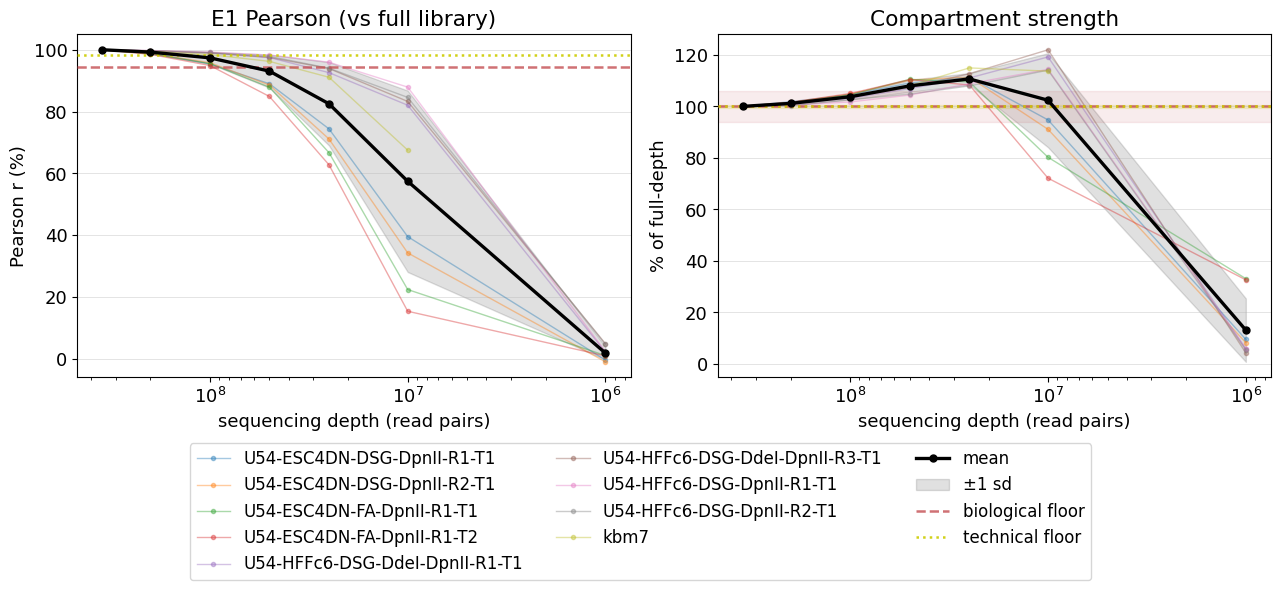

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

plot_panel(axes[0],
           library_curves(comp_summary, "E1_pearson", "percent"),
           "Pearson r (%)", "E1 Pearson (vs full library)",
           bio_floor=floor_bio_E1, tech_floor=floor_tech_E1)

plot_panel(axes[1],
           library_curves(comp_summary, "comp_strength", "normalized"),
           "% of full-depth", "Compartment strength",
           bio_floor=100, tech_floor=100,
           bio_spread=floor_bio_strength, tech_spread=floor_tech_strength)

e1_curves = library_curves(comp_summary, "E1_pearson", "percent")
report_crossing("E1 Pearson", e1_curves, floor_bio_E1)

add_legend(fig, axes[0], bbox_y=-0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig3_compartments_vs_depth.png", dpi=300, bbox_inches="tight")
plt.show()

## Figure 4 - saddle plots

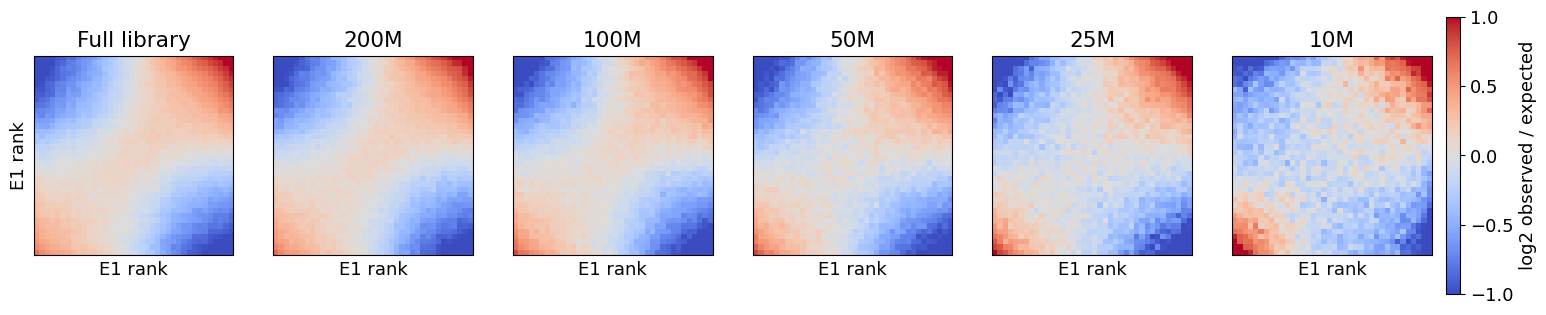

In [35]:
SADDLE_DEPTHS = [FULL_DEPTH_READS, 200_000_000, 100_000_000,
                 50_000_000, 25_000_000, 10_000_000]


def depth_name(depth):
    '''Short label of a depth.'''
    if depth == FULL_DEPTH_READS:
        return "Full library"
    return f"{depth // 1_000_000}M"


def entity_at_depth(sample_name, srr, depth):
    '''First cached cooler of this library at the given depth.'''
    for entity in list_entities(sample_name, srr):
        if depth == FULL_DEPTH_READS and entity["role"] == "full":
            return entity["entity_id"]
        if entity["role"] == "subsample" and entity["depth"] == depth:
            if is_cached(saddle_path(sample_name, entity["entity_id"])):
                return entity["entity_id"]
    return None


sample_name, srr = SADDLE_LIBRARY
fig, axes = plt.subplots(1, len(SADDLE_DEPTHS), figsize=(3.1 * len(SADDLE_DEPTHS), 3.6))

for ax, depth in zip(axes, SADDLE_DEPTHS):
    entity_id = entity_at_depth(sample_name, srr, depth)
    if entity_id is None:
        ax.axis("off")
        continue

    matrix = load_saddle(sample_name, entity_id)["matrix"][1:-1, 1:-1]
    image = ax.imshow(np.log2(matrix), cmap="coolwarm", vmin=-1, vmax=1,
                      origin="lower", interpolation="none")
    ax.set_title(depth_name(depth))
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("E1 rank")

axes[0].set_ylabel("E1 rank")
fig.colorbar(image, ax=axes, fraction=0.02, pad=0.01,
             label="log2 observed / expected")
fig.savefig(FIGURES_DIR / "fig4_saddle_by_depth.png", dpi=300, bbox_inches="tight")
plt.show()


## Figures 5 and S2 - insulation at the 100 kb and 50 kb windows

insulation Pearson (100 kb): crosses 82.6% at 30.3M read pairs, from 16.3M to 53.0M


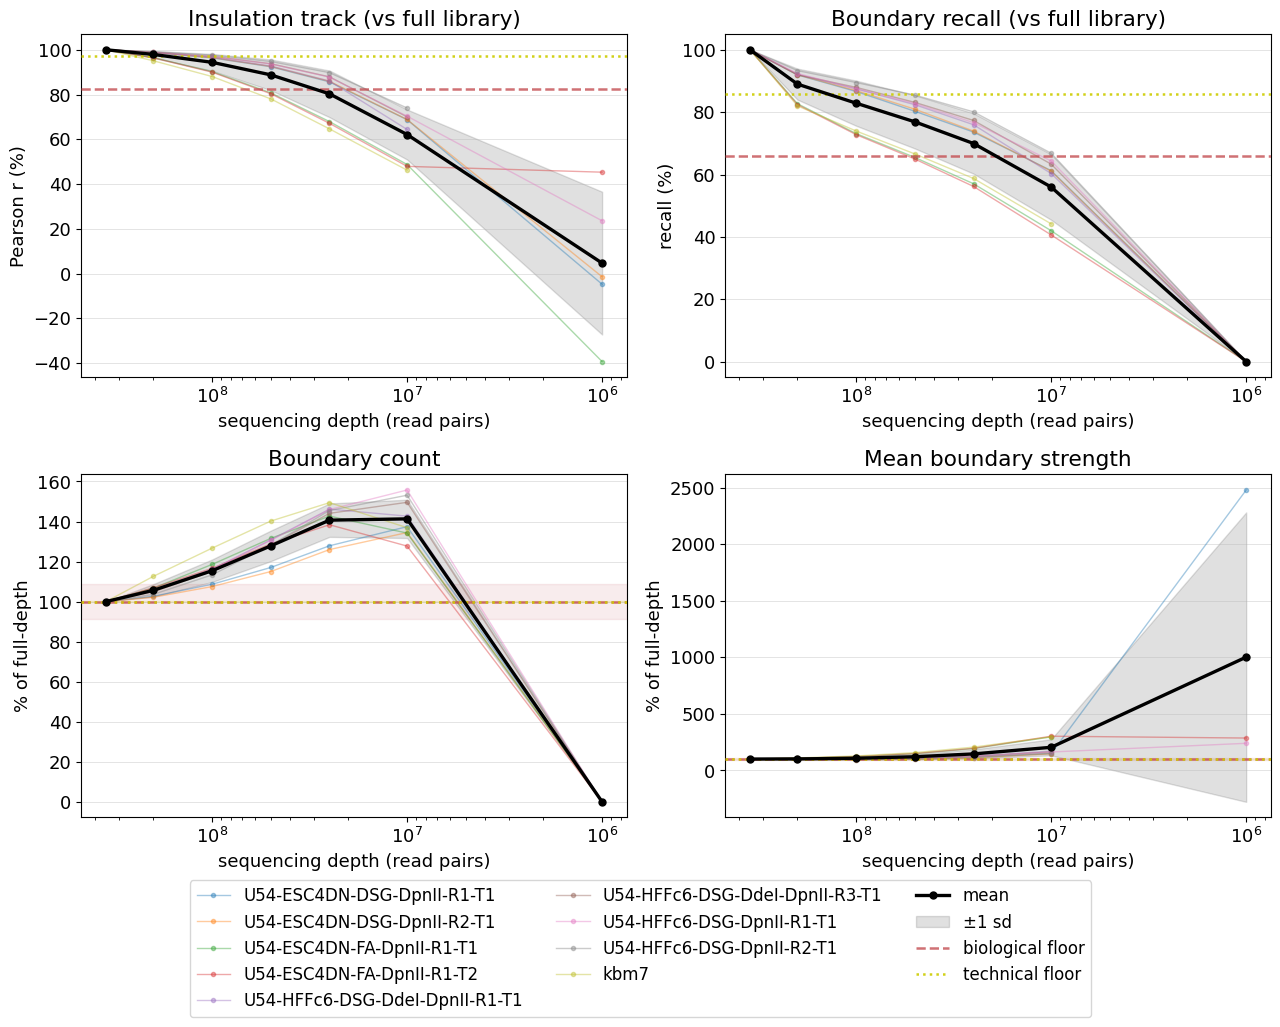

insulation Pearson (50 kb): crosses 82.6% at 75.0M read pairs, from 34.5M to 122.7M


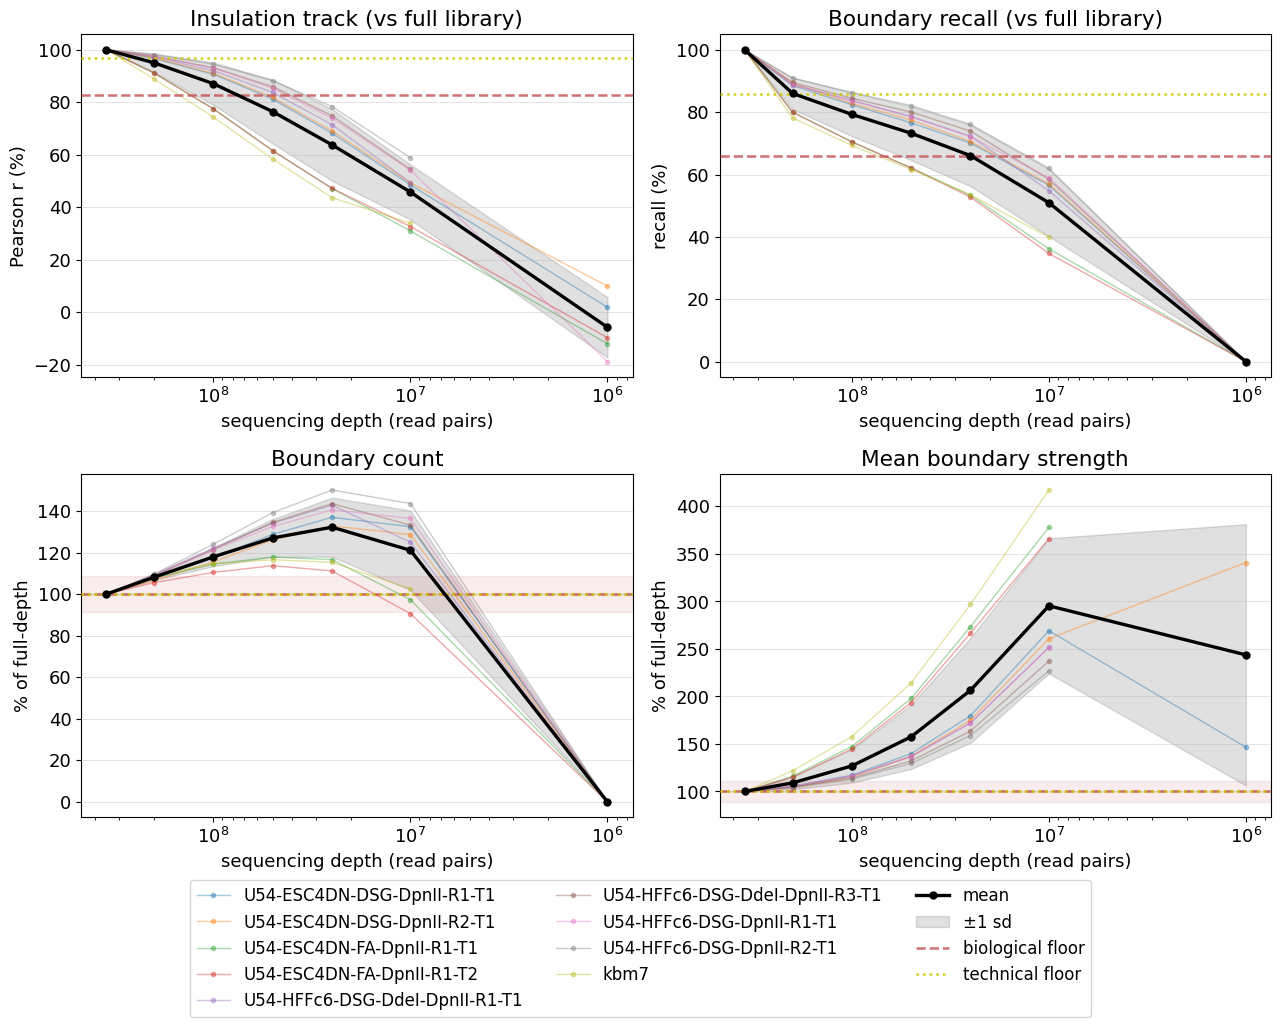

In [72]:
def insulation_figure(window, tolerance, name, filename):
    '''Four insulation panels for one window and one boundary tolerance.'''

    ins_curves = library_curves(insul_summary, "ins_pearson", "percent",
                                window=window, tolerance=tolerance)
    report_crossing(f"insulation Pearson ({window // 1000} kb)", ins_curves, floor_bio_ins)
    
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    plot_panel(axes[0, 0],
               library_curves(insul_summary, "ins_pearson", "percent",
                              window=window, tolerance=tolerance),
               "Pearson r (%)", "Insulation track (vs full library)",
               bio_floor=floor_bio_ins, tech_floor=floor_tech_ins)

    plot_panel(axes[0, 1],
               library_curves(insul_summary, "b_recall", "percent",
                              window=window, tolerance=tolerance),
               "recall (%)", "Boundary recall (vs full library)",
               bio_floor=floor_bio_recall, tech_floor=floor_tech_recall)

    plot_panel(axes[1, 0],
               library_curves(insul_summary, "n_boundaries", "normalized",
                              window=window, tolerance=tolerance),
               "% of full-depth", "Boundary count",
               bio_floor=100, tech_floor=100,
               bio_spread=floor_bio_count, tech_spread=floor_tech_count)

    plot_panel(axes[1, 1],
               library_curves(insul_summary, "mean_boundary_strength", "normalized",
                              window=window, tolerance=tolerance),
               "% of full-depth", "Mean boundary strength",
               bio_floor=100, tech_floor=100,
               bio_spread=floor_bio_bstrength, tech_spread=floor_tech_bstrength)

    add_legend(fig, axes[0, 0], bbox_y=-0.15)

    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"{filename}.png", dpi=300, bbox_inches="tight")
    plt.show()


insulation_figure(MAIN_WINDOW, MAIN_TOLERANCE, "Figure 5", "fig5_insulation_100kb")
insulation_figure(50_000, MAIN_TOLERANCE, "Figure S2", "figS2_insulation_50kb")

## Figure S3 - boundary recall at four tolerances

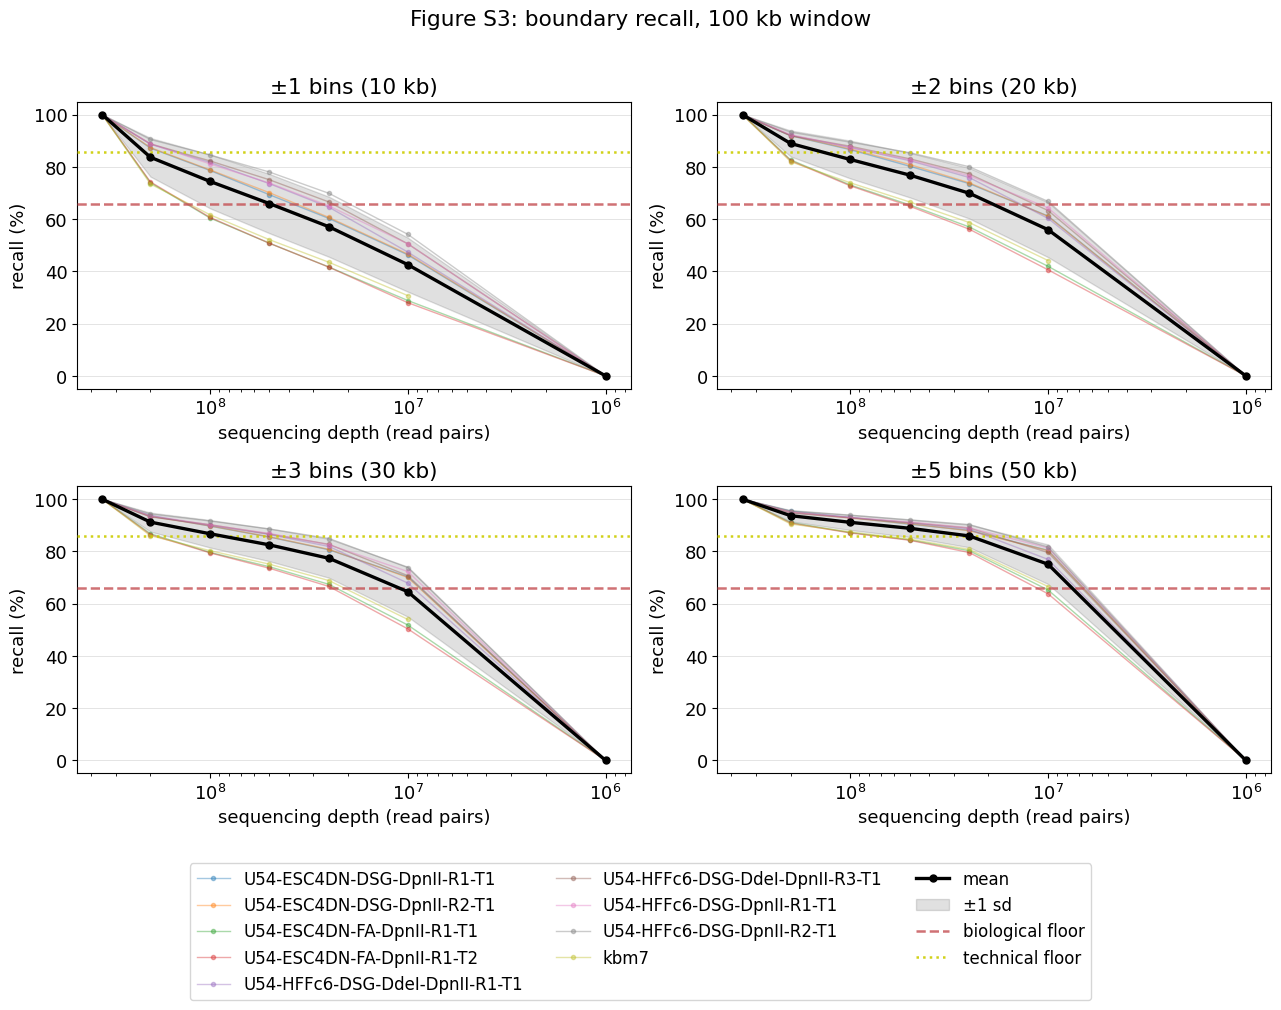

In [64]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, letter, tolerance in zip(axes.flatten(), panel_names, TOLERANCES):
    plot_panel(ax,
               library_curves(insul_summary, "b_recall", "percent",
                              window=MAIN_WINDOW, tolerance=tolerance),
               "recall (%)",
               f"±{tolerance} bins ({tolerance * RES_INSULATION // 1000} kb)",
               bio_floor=floor_bio_recall,
               tech_floor=floor_tech_recall)

fig.suptitle(f"Figure S3: boundary recall, {MAIN_WINDOW // 1000} kb window", y=1.01)
fig.tight_layout(rect=[0, 0.08, 1, 1])
add_legend(fig, axes[0,0], bbox_y=-0.1)
fig.savefig(FIGURES_DIR / "figS3_boundary_recall_tolerances.png", dpi=300,
            bbox_inches="tight")
plt.show()

## Tables S4 and S5

In [67]:
def metrics_table(summary, metrics, window=None, tolerance=None):
    '''Mean and s.d. across libraries of each metric, one row per depth.

    Returns two tables: one with separate mean/SD columns for csv,
    one with "mean ± SD" strings for display.
    '''
    csv_rows = []
    display_rows = []
    curves = {label: library_curves(summary, column, mode, window, tolerance)
              for column, label, mode in metrics}

    for depth in DEPTHS:
        csv_row = {"Depth": f"{depth // 1_000_000}M"}
        disp_row = {"Depth": f"{depth // 1_000_000}M"}
        n_libraries = 0

        for column, label, mode in metrics:
            values = curves[label][depth].dropna()
            mean = round(values.mean(), 1)
            sd = round(values.std(), 1)
            csv_row[f"{label} mean (%)"] = mean
            csv_row[f"{label} SD (%)"] = sd
            disp_row[f"{label} (%)"] = f"{mean} ± {sd}"
            n_libraries = max(n_libraries, len(values))

        csv_row["n"] = n_libraries
        disp_row["n"] = n_libraries
        csv_rows.append(csv_row)
        display_rows.append(disp_row)

    return pd.DataFrame(csv_rows), pd.DataFrame(display_rows)


csv_s4, disp_s4 = metrics_table(comp_summary, [
    ("E1_pearson", "E1 Pearson", "percent"),
    ("E1_sign_agree", "Sign agree", "percent"),
    ("E1_spearman", "E1 Spearman", "percent"),
    ("comp_strength", "Comp. strength", "normalized"),
])
csv_s4.to_csv(TABLES_DIR / "tableS4_compartment_metrics.csv", index=False)
display(disp_s4)



,Depth,E1 Pearson (%),Sign agree (%),E1 Spearman (%),Comp. strength (%),n
0,200M,99.2 ± 0.5,97.9 ± 1.0,99.2 ± 0.5,101.2 ± 0.5,9
1,100M,97.4 ± 1.9,95.9 ± 2.2,97.4 ± 1.8,103.7 ± 1.1,9
2,50M,93.1 ± 5.4,93.0 ± 4.0,93.5 ± 4.8,108.0 ± 2.3,9
3,25M,82.5 ± 13.5,87.6 ± 7.8,84.7 ± 12.1,110.7 ± 2.3,9
4,10M,57.5 ± 29.3,76.0 ± 14.5,61.3 ± 29.8,102.4 ± 18.3,9
5,1M,1.9 ± 2.1,51.0 ± 0.8,2.0 ± 2.1,13.1 ± 12.3,8


In [68]:
csv_s5, disp_s5 = metrics_table(insul_summary, [
    ("ins_pearson", "Ins. Pearson", "percent"),
    ("b_f1", "Boundary F1", "percent"),
    ("b_precision", "Boundary prec.", "percent"),
    ("b_recall", "Boundary recall", "percent"),
    ("n_boundaries", "Boundary count", "normalized"),
    ("mean_boundary_strength", "Boundary strength", "normalized"),
], window=MAIN_WINDOW, tolerance=MAIN_TOLERANCE)
csv_s5.to_csv(TABLES_DIR / "tableS5_insulation_metrics.csv", index=False)
display(disp_s5)

,Depth,Ins. Pearson (%),Boundary F1 (%),Boundary prec. (%),Boundary recall (%),Boundary count (%),Boundary strength (%),n
0,200M,97.9 ± 1.5,86.6 ± 5.8,84.4 ± 6.6,89.0 ± 5.0,105.6 ± 3.1,101.5 ± 5.0,9
1,100M,94.4 ± 3.8,77.1 ± 8.1,72.1 ± 8.7,82.9 ± 7.2,115.4 ± 5.6,107.2 ± 12.7,9
2,50M,88.8 ± 6.9,67.6 ± 8.6,60.5 ± 8.8,76.9 ± 8.5,127.8 ± 7.6,120.4 ± 23.5,9
3,25M,80.3 ± 10.4,58.2 ± 8.4,50.0 ± 7.7,69.9 ± 9.7,140.7 ± 8.4,145.5 ± 39.8,9
4,10M,62.1 ± 11.2,46.3 ± 7.5,39.6 ± 5.8,56.0 ± 10.5,141.3 ± 9.6,204.0 ± 71.2,9
5,1M,4.7 ± 31.9,0.0 ± nan,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,1001.7 ± 1280.3,8
